# Traitez les images pour le système embarqué d’une voiture autonome : Modèle

Ce projet vise à développer un modèle capable de de reconnaître différent indice visuel dans un cas de voiture autonome. Notre jeu de données est disponible à ce lien: www.cityscapes-dataset.com/dataset-overview/. Les deux dossiers que nous récupérons sont celui avec les images non modifiés (leftImg8bit), et celui déjà traité avec un masque (gtFine). Ils contiennent les même images mais avec un traitement différent. Le premier agira comme nos variables prédicatives, et le deuxième est notre cible.

## Import

In [1]:
import numpy as np
from PIL import Image
from matplotlib import pyplot as plt

## Récupération des données

### Exploration

Nous allons commencer par regarder les images que nous avons pour en apprendre plus sur ces dernières.

In [2]:
IMG_PATH ="data/P8_Cityscapes_leftImg8bit_trainvaltest/leftImg8bit/train/aachen/aachen_000009_000019_leftImg8bit.png"
MASK_PATH = IMG_PATH.replace("leftImg8bit", "gtFine")
MASK_PATH = MASK_PATH.replace(".png", "_labelIds.png")
IMG = np.array(Image.open(IMG_PATH))
MASK = np.array(Image.open(MASK_PATH))

print(IMG.shape, MASK.shape)

(1024, 2048, 3) (1024, 2048)


Les deux types d'images qui nous intéressent sont toutes deux en format 1024 X 2048 et les images non traité ont un dimension en plus contenant les valeurs rgb.

### Réduction des labels

Nous avons appris dans la description des données qu'il y avaient 35 labels en tout ranger dans 8 catégories. Le système de décision n'aura besoin que des 8 catégories, nous pouvons donc réduire la taille des labels possibles, ce qui va nous permettre d'accélerer la vitesse du modèle et lui permettra de mieux généraliser et donc de mieux performer.

Nous avons trouvé la liste suivante dans le GitHub lié au jeu de données. Nous allons donc pouvoir procéder à la réduciton des labels.

In [3]:
labels=[
	('unlabeled', 0, 'void', 0),
	('egovehicle', 1, 'void', 0),
	('rectificationborder', 2, 'void', 0),
	('outofroi', 3, 'void', 0),
	('static', 4, 'void', 0),
	('dynamic', 5, 'void', 0),
	('ground', 6, 'void', 0),
	('road', 7, 'flat', 1),
	('sidewalk', 8, 'flat', 1),
	('parking', 9, 'flat', 1),
	('railtrack', 10, 'flat', 1),
	('building', 11, 'construction', 2),
	('wall', 12, 'construction', 2),
	('fence', 13, 'construction', 2),
	('guardrail', 14, 'construction', 2),
	('bridge', 15, 'construction', 2),
	('tunnel', 16, 'construction', 2),
	('pole', 17, 'object', 3),
	('polegroup', 18, 'object', 3),
	('trafficlight', 19, 'object', 3),
	('trafficsign', 20, 'object', 3),
	('vegetation', 21, 'nature', 4),
	('terrain', 22, 'nature', 4),
	('sky', 23, 'sky', 5),
	('person', 24, 'human', 6),
	('rider', 25, 'human', 6),
	('car', 26, 'vehicle', 7),
	('truck', 27, 'vehicle', 7),
	('bus', 28, 'vehicle', 7),
	('caravan', 29, 'vehicle', 7),
	('trailer', 30, 'vehicle', 7),
	('train', 31, 'vehicle', 7),
	('motorcycle', 32, 'vehicle', 7),
	('bicycle', 33, 'vehicle', 7),
	('licenseplate', 34, 'vehicle', 7)
]

mapping_array = np.array([x[3] for x in labels])
print(mapping_array)
CAT_MASK = mapping_array[MASK]
print(np.unique(MASK))
print(np.unique(CAT_MASK))

[0 0 0 0 0 0 0 1 1 1 1 2 2 2 2 2 2 3 3 3 3 4 4 5 6 6 7 7 7 7 7 7 7 7 7]
[ 1  3  4  6  7  8  9 11 12 17 19 20 21 23 24 26 32]
[0 1 2 3 4 5 6 7]


Visualisons cette différence en affichant l'image de base et nos masques.

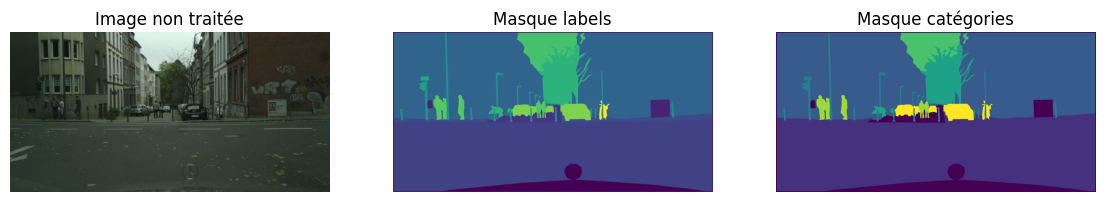

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(14, 6))
for ax in axs:
    ax.axis("off")

axs[0].imshow(IMG)
axs[0].set_title("Image non traitée")

axs[1].imshow(MASK)
axs[1].set_title("Masque labels")

axs[2].imshow(CAT_MASK)
axs[2].set_title("Masque catégories")

plt.show()

C'est subtile, mais on peut voir par exemple que le scooter à droite de l'image est affiché d'une couleur différente dans le masque avec les labels, alors qu'il est de la même couleur dans le masque avec seulement les catégories.